<p style="background-color:#f8f9fa; 
          padding:18px; 
          color:#111;
          font-size:16px;
          border-width:2px; 
          border-color:#e0e0e0; 
          border-style:solid;
          border-radius:6px">
⛳ <strong>Graph Surgeon: Automated ONNX Optimization Pipeline</strong><br><br>
Most submitted networks carry hidden bloat — redundant nodes, unfused operations, and constant subgraphs computed at runtime instead of compile time.<br><br>
This notebook stacks <strong>two optimization engines</strong> in sequence, each one correctness-preserving:<br><br>
🔬 <strong>onnxoptimizer</strong> — 47 graph rewrite passes: dead code elimination, common subexpression removal, node fusion, and no-op cleanup<br>
⚡ <strong>onnxscript optimizer</strong> — Microsoft's IR-level passes: catches redundancies the other two miss<br><br>
🎯 Same outputs. Fewer nodes. Lower memory. Higher score.
</p>

# ⚙️ Setup

## 🖥️ Env

In [1]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

!pip install -q onnxsim 2>/dev/null
!pip install -q onnxscript 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 6.6 MB/s eta 0:00:00


$$ $$

## 🧬 Load Public Submission

In [2]:
!rm -r /kaggle/working/submission 2>/dev/null
!cp /kaggle/input/notebooks/massimilianoghiotto/convolution-series-part-4/submission.zip /kaggle/working/submission.zip
!unzip -q /kaggle/working/submission.zip -d /kaggle/working/submission
!rm /kaggle/working/submission.zip 
!ls -la submission

total 24
drwxr-xr-x 3 root root  4096 Jun 13 00:35 .
drwxr-xr-x 3 root root  4096 Jun 13 00:35 ..
drwxr-xr-x 2 root root 16384 Jun 13 00:35 submission


In [3]:
SRC = "/kaggle/working/submission/submission"

$$ $$

 ## 📦 Imports

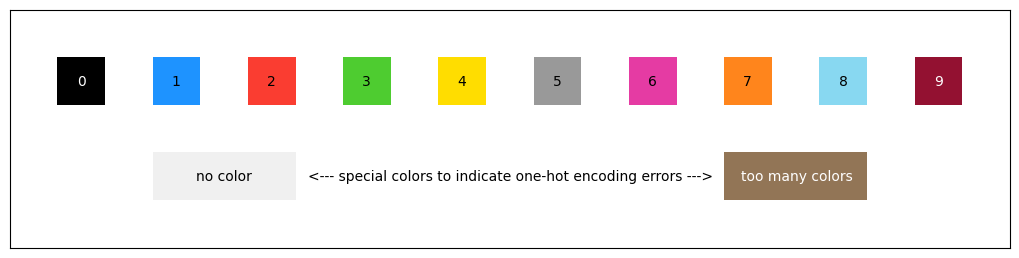

In [4]:
import sys
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import *
show_legend()

In [5]:
import math, glob, os
import copy
from tqdm.auto import tqdm
from collections import defaultdict, Counter


import pandas as pd
import numpy as np


import onnx
from onnx import helper, TensorProto, numpy_helper
import onnxruntime

$$ $$
## ƒ Utils

In [6]:
def score_task(task_num, network, verify_on_data = True):
    """Returns (points, memory, params) or None if failed."""
    filename = f"task{task_num:03d}.onnx"
    onnx.save(network, filename)
    if not check_network(filename):
        return None

    try:
        sanitized = onnx.load(filename)
        for node in sanitized.graph.node:
            node.name = node.output[0]
            if "kernel_time" in node.name:
                return None
        options = onnxruntime.SessionOptions()
        options.enable_profiling = True
        options.graph_optimization_level = onnxruntime.GraphOptimizationLevel.ORT_DISABLE_ALL
        options.profile_file_prefix = f"{task_num:03}"
        session = onnxruntime.InferenceSession(sanitized.SerializeToString(), options)
    except Exception:
        return None

    if verify_on_data:
        examples = load_examples(task_num)
        agi_r, agi_w, _ = verify_subset(session, examples["train"] + examples["test"])
        gen_r, gen_w, _ = verify_subset(session, examples["arc-gen"])
        if agi_w + gen_w > 0:
            return None  # incorrect

    memory, params = score_network(sanitized, session.end_profiling())
    if memory is None or params is None or memory < 0 or params < 0:
        return None

    points = max(1.0, 25.0 - math.log(max(1.0, memory + params)))
    return points, memory, params

$$ $$

## 💯 Initial Score

In [7]:
task_paths = sorted(glob.glob(f"{SRC}/task*.onnx"))
INITIAL_SCORE = 0.0

for path in tqdm(task_paths):
    task_num = int(os.path.basename(path).split(".")[0].replace("task",""))
    
    try:
        network = onnx.load(path)
    

        result = score_task(task_num, network, verify_on_data = False)
        points, mem, params = result

    except Exception as e:
        print(f"[{t}] {e}")
        print(f"----------------------------------------\n")
        points = 0

    !rm *.json 2>/dev/null
    !rm *.onnx 2>/dev/null
    INITIAL_SCORE += points
    
print(f"💯 Initial Score: {INITIAL_SCORE:.5f}")

  0%|          | 0/400 [00:00<?, ?it/s]

💯 Initial Score: 6372.64885


$$ $$

$$ $$

# 🧹 Optimizations

## 🪄 ONNX Simplifier

<p style="background-color:#e6f7ff; 
          padding:15px; 
          color:#111;
          font-size:16px;
          border-width:3px; 
          border-color:#d0eefc; 
          border-style:solid;
          border-radius:6px">
🪄  <strong>ONNX Simplifier — Constant Folding & Subgraph Elimination</strong><br><br>
Many exported networks compute values at runtime that could be resolved at <em>build time</em>. A chain of ops on constant tensors runs every inference — wasting both intermediate memory and node count.<br><br>
<code>onnxsim</code> fixes this by <strong>actually running</strong> the graph, identifying subgraphs with constant outputs, and replacing them with their precomputed results.<br><br>
<strong>What it catches:</strong><br>
📐 <strong>Constant folding</strong> — subgraphs fed only by initializers get collapsed into a single Constant<br>
🚫 <strong>Redundant ops</strong> — Identity, no-op Reshape, Cast-to-same-type, Transpose with identity permutation<br>
🔗 <strong>Shape simplification</strong> — Shape→Gather→Concat chains resolved to static values<br><br>
<strong>Why it matters for NeuroGolf:</strong><br>
Every eliminated intermediate tensor saves <code>num_elements × dtype_size</code> bytes from the memory cost. Fewer nodes = fewer intermediates = lower cost = higher score.<br><br>
<code>cost = total_parameters + total_memory_in_bytes</code><br>
<code>score = max(1, 25 - ln(cost))</code><br><br>
Same outputs. Smaller graph. <strong>Higher score</strong>. 🎯
</p>

In [8]:
from onnxsim import simplify

improved = []
failures = []

for path in tqdm(sorted(glob.glob(f"{SRC}/task*.onnx"))):
    task_num = int(os.path.basename(path).replace("task","").replace(".onnx",""))
    
    !rm *.onnx 2>/dev/null
    !rm *.json 2>/dev/null
    
    network = onnx.load(path)
    
    try:
        score_before, mem_before, params_before = score_task(task_num, network, verify_on_data = False)
    except:
        continue
    
    try:
        optimized, ok = simplify(copy.deepcopy(network))
        if not ok:
            failures.append((task_num, "simplify returned False"))
            continue
        
        onnx.checker.check_model(optimized)
        score_after, mem_after, params_after = score_task(task_num, optimized, verify_on_data = False)
        
        delta = score_after - score_before
        if score_after > score_before:
            improved.append((task_num, mem_before, mem_after, params_before, params_after,
                            score_before, score_after, delta))
            onnx.save(optimized, path)
    
    except Exception as e:
        failures.append((task_num, str(e)[:80]))

# Sort by biggest score gain
improved.sort(key=lambda x: -x[7])

print(f"🪄 {len(improved)} tasks improved, {len(failures)} failed\n")
print(f"{'Task':>6} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
for task_num, mb, ma, pb, pa, sb, sa, delta in improved[:20]:
    print(f"  {task_num:03d}    {mb:>8}   {ma:>8}   {pb:>12}   {pa:>11}   +{delta:.4f}")

total_gain = sum(r[7] for r in improved)
print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
if failures:
    print(f"⚠️  {len(failures)} tasks failed simplification")

  0%|          | 0/400 [00:00<?, ?it/s]

🪄 40 tasks improved, 0 failed

  Task Mem Before  Mem After  Params Before  Params After  Score Δ
────── ────────── ────────── ────────────── ───────────── ────────
  004       46080      40960           1045          1045   +0.1150
  358       45069      39189            220          2019   +0.0944
  285      121246     110254           2488          2538   +0.0926
  005       92970      85009           2837          2837   +0.0868
  173       92028      85260           2200          2200   +0.0745
  205       67911      65211            981           981   +0.0400
  076       77850      75068           2114          2114   +0.0354
  369        7400       7200            130           129   +0.0271
  383       38454      37554           1052          1052   +0.0230
  374       13208      12808            134           233   +0.0228
  034       11421      11193             77            77   +0.0200
  343       27208      26668            248           248   +0.0199
  370       55222  

$$ $$

## 📜 ONNX Script

<p style="background-color:#f0e6ff; 
          padding:15px; 
          color:#111;
          font-size:16px;
          border-width:3px; 
          border-color:#e0d0f5; 
          border-style:solid;
          border-radius:6px">
📜 <strong>onnxscript Optimizer — IR-Level Graph Rewriting</strong><br><br>
Microsoft's <code>onnxscript.optimizer</code> operates on ONNX's intermediate representation directly — a different engine from <code>onnxsim</code>, catching redundancies left behind.<br><br>
It runs multiple iterations: each pass can expose new opportunities for the next — a constant fold reveals a no-op, the no-op removal reveals a dead branch, and so on.<br><br>
<strong>What it catches:</strong><br>
🔄 <strong>Iterative constant folding</strong> — multi-pass: fold → simplify → fold again until nothing changes<br>
💀 <strong>Dead code elimination</strong> — nodes whose outputs feed nothing get removed along with their intermediates<br>
🧩 <strong>Shape-aware rewrites</strong> — leverages full shape inference to resolve dynamic-looking patterns into static ones<br><br>
<strong>Why stack it after onnxsim:</strong><br>
Different optimization engines have different blind spots. Running <code>onnxsim</code> first handles the bulk; <code>onnxscript</code> then sweeps for what remains — often shaving a few more intermediate tensors that translate directly to memory savings.<br><br>
Same outputs. Cleaner graph. <strong>Higher score</strong>. 🎯
</p>

In [9]:
import onnxscript

improved = []
failures = []

for path in tqdm(sorted(glob.glob(f"{SRC}/task*.onnx"))):
    task_num = int(os.path.basename(path).replace("task","").replace(".onnx",""))
    
    !rm *.onnx 2>/dev/null
    !rm *.json 2>/dev/null
    
    network = onnx.load(path)
    
    try:
        score_before, mem_before, params_before = score_task(task_num, network, verify_on_data=False)
    except:
        continue
    
    try:
        optimized = onnxscript.optimizer.optimize(
            copy.deepcopy(network),
            num_iterations=8,
            onnx_shape_inference=True,
        )
        onnx.checker.check_model(optimized)
        score_after, mem_after, params_after = score_task(task_num, optimized)
        
        if score_after > score_before:
            delta = score_after - score_before
            improved.append((task_num, mem_before, mem_after, params_before, params_after,
                            score_before, score_after, delta))
            onnx.save(optimized, path)
    
    except Exception as e:
        print(f"❌ '{task_num}' {e}")
        failures.append((task_num, str(e)[:80]))

# Sort by biggest score gain
improved.sort(key=lambda x: -x[7])

print(f"⚡ {len(improved)} tasks improved, {len(failures)} failed\n")
print(f"{'Task':>6} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
for task_num, mb, ma, pb, pa, sb, sa, delta in improved[:20]:
    print(f"  {task_num:03d}    {mb:>8}   {ma:>8}   {pb:>12}   {pa:>11}   +{delta:.4f}")

total_gain = sum(r[7] for r in improved)
print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
if failures:
    print(f"⚠️  {len(failures)} tasks failed optimization")

  0%|          | 0/400 [00:00<?, ?it/s]

❌ '112' Node(node_Clip_0) with schema(::Clip:6) has input size 3 not in range [min=1, max=1].

==> Context: Bad node spec for node. Name: node_Clip_0 OpType: Clip
❌ '219' cannot unpack non-iterable NoneType object
⚡ 2 tasks improved, 2 failed

  Task Mem Before  Mem After  Params Before  Params After  Score Δ
────── ────────── ────────── ────────────── ───────────── ────────
  071       63080      61358            468           468   +0.0275
  090       60840      60214            578           569   +0.0104

📊 Total score gain: +0.0379 across 2 tasks
⚠️  2 tasks failed optimization


$$ $$

# 💯 Improved Score

In [10]:
task_paths = sorted(glob.glob(f"{SRC}/task*.onnx"))
IMPROVED_SCORE = 0.0

for path in tqdm(task_paths):
    task_num = int(os.path.basename(path).split(".")[0].replace("task",""))
    
    try:
        network = onnx.load(path)
    

        result = score_task(task_num, network, verify_on_data = False)
        points, mem, params = result

    except Exception as e:
        print(f"[{t}] {e}")
        print(f"----------------------------------------\n")
        points = 0

    !rm *.json 2>/dev/null
    !rm *.onnx 2>/dev/null
    IMPROVED_SCORE += points


print(f"💯 Score: {INITIAL_SCORE:.4f} → {IMPROVED_SCORE:.4f}  (Δ{IMPROVED_SCORE - INITIAL_SCORE:+.5f})")

  0%|          | 0/400 [00:00<?, ?it/s]

💯 Score: 6372.6489 → 6373.5108  (Δ+0.86198)


$$ $$

# 📤 Submit

In [11]:
import zipfile

output_filename = '/kaggle/working/submission.zip'

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SRC):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, os.path.join(SRC, '..')))
!rm -r submission

In [12]:
ls

__notebook__.ipynb  submission.zip
